#### Chain Of Thoughts With RAG
What is Chain-of-Thought (CoT) in RAG?

CoT reasoning breaks down a complex question into intermediate steps, and allows retrieval + reflection at each step before answering.

User Query
   ↓
- Step 1: Decompose question → sub-steps (Reason)
- Step 2: Retrieve docs per step (Act)
- Step 3: Combine context (Observe)
- Step 4: Final answer generation (Reflect)

In [42]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END
from langchain_core.output_parsers import StrOutputParser

In [43]:
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

# --- CHECKPOINT 1: File Discovery ---
pdf_paths = [
    "./pdf/Earnings-Presentation-Q3-2025-Final.pdf",
    "./pdf/ICIBM 2025_submission_43_paper_v2.pdf",
]

docs = []
for path in pdf_paths:
    if os.path.exists(path):
        loader = PyPDFLoader(path)
        data = loader.load()
        print(f"✅ Loaded {len(data)} pages from {path}")
        docs.extend(data)
    else:
        print(f"❌ File NOT found: {os.path.abspath(path)}")

# --- CHECKPOINT 2: Data Validation ---
if not docs:
    raise ValueError("No documents were loaded. Check your file paths or PDF content!")

# Ensure we aren't accidentally overwriting 'docs' here with a WebBaseLoader!

# --- CHECKPOINT 3: Splitting ---
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
)
doc_splits = text_splitter.split_documents(docs)
print(f"✂️ Created {len(doc_splits)} text chunks.")

if not doc_splits:
    raise ValueError("Documents were loaded, but splitting resulted in 0 chunks. Are the PDFs empty or images?")

# --- CHECKPOINT 4: Vector Store ---
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(documents=doc_splits, embedding=embedding)
retriever = vectorstore.as_retriever()
print("🚀 Vector store successfully built!")

✅ Loaded 18 pages from ./pdf/Earnings-Presentation-Q3-2025-Final.pdf
✅ Loaded 10 pages from ./pdf/ICIBM 2025_submission_43_paper_v2.pdf
✂️ Created 92 text chunks.
🚀 Vector store successfully built!


In [44]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
llm=init_chat_model("openai:gpt-4o")

In [45]:
# -------------------------------
# 2. LangGraph State Definition
# -------------------------------
class RAGCoTState(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

In [46]:
# -------------------------------
# 3. Nodes
# -------------------------------
from langchain_core.prompts import ChatPromptTemplate

_plan_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a reasoning assistant. "
        "Break the user's question into 2-3 reasoning steps that can be answered "
        "using ONLY the provided context. "
        "Return a numbered list only, no extra text."
    ),
    (
        "human",
        "Context from research paper:\n{context}\n\nQuestion: {question}"
    )
])

_plan_chain = _plan_prompt | llm | StrOutputParser()

def plan_steps(state: RAGCoTState) -> RAGCoTState:
    context = "\n\n".join(doc.page_content for doc in state.retrieved_docs)

    result = _plan_chain.invoke({
        "context":  context,
        "question": state.question
    })

    subqs = [line.strip("- ") for line in result.split("\n") if line.strip()]
    return state.model_copy(update={"sub_steps": subqs})

In [47]:
def retrieve_per_step(state: RAGCoTState) -> RAGCoTState:
    THRESHOLD = 0.30
    K = 5
    FETCH_K = 20
    LAMBDA_MULT = 0.6

    try:
        docs_with_scores = vectorstore.similarity_search_with_relevance_scores(
            state.question,      # always the original question, no condition needed
            k=K,
            search_type="mmr",
            search_kwargs={"fetch_k": FETCH_K, "lambda_mult": LAMBDA_MULT}
        )
    except Exception as e:
        print(f"[Retrieval Error]: {e}")
        return state.model_copy(update={"retrieved_docs": []})

    filtered = [
        doc for doc, score in docs_with_scores
        if score >= THRESHOLD
    ]
    return state.model_copy(update={"retrieved_docs": filtered})

In [48]:
# c. Generate Final Answer
def generate_answer(state: RAGCoTState) -> RAGCoTState:
    
    if not state.retrieved_docs:
        return state.model_copy(update={
            "answer": "I could not find relevant information in the knowledge base to answer this question."
        })
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    #print("=== CONTEXT SENT TO LLM ===")
    #print(context[:500])   # see what it actually retrieved
    #print("===========================")
    prompt = f"""
You are answering a complex question using step-by-step reasoning.

Question: {state.question}

Reasoning steps to follow:
{chr(10).join(f"Step {i+1}: {step}" for i, step in enumerate(state.sub_steps))}

Retrieved evidence for each step:
{context}

Now work through each step one by one using the evidence above, 
then synthesize a final answer at the end.

Step 1 reasoning:
Step 2 reasoning:
Step 3 reasoning:
Final Answer:
"""
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": result})

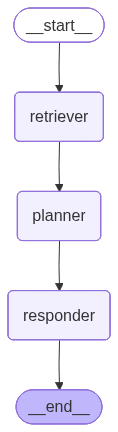

In [49]:
# -------------------------------
# 4. LangGraph Graph
# -------------------------------
builder = StateGraph(RAGCoTState)
builder.add_node("planner", plan_steps)
builder.add_node("retriever", retrieve_per_step)
builder.add_node("responder", generate_answer)

builder.set_entry_point("retriever")
builder.add_edge("retriever", "planner")
builder.add_edge("planner", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [50]:
# -------------------------------
# 5. Run CoT RAG Agent
# -------------------------------
if __name__ == "__main__":
    query = "what are metaphor prompt approaches?"
    state = RAGCoTState(question=query)
    final = graph.invoke(state)

    print("\n🪜 Reasoning Steps:", final["sub_steps"])
    print("\n✅ Final Answer:\n", final["answer"])


🪜 Reasoning Steps: ['1. MetaphorPrompt employs a linear, segmented process that involves isolated steps such as context identification, verb/preposition identification, causal event extraction, and standalone relational graph generation. This process is rigid and creates fragmented outputs due to limited cross-phase integration.', '2. MetaphorPrompt2 utilizes a fluid, adaptive flow where context informs entity functional roles, and structural relation identification precedes metaphor generation. This approach facilitates the creation of familiar, real-world metaphors, enabling the better understanding and extraction of causal relationships by LLMs. It integrates identified relationships and functional roles for metaphor generation, ensuring that metaphorical mappings preserve essential causal relationships.']

✅ Final Answer:
 Sure, let's work through each step using the retrieved evidence.

**Step 1 Reasoning:**
MetaphorPrompt employs a linear, segmented process that involves isolate